# Turbofan Engine RUL Prediction
### Project 6 – Predictive Maintenance | UCT ML Internship

**Objective:** Predict the Remaining Useful Life (RUL) of turbofan engines before failure using multivariate time series sensor data.

**Dataset:** NASA CMAPSS (Commercial Modular Aero-Propulsion System Simulation)
- FD001: 1 condition, 1 fault mode
- FD002: 6 conditions, 1 fault mode
- FD003: 1 condition, 2 fault modes
- FD004: 6 conditions, 2 fault modes

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# For deep learning (optional - comment out if not installed)
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, LSTM, Dropout, Conv1D, MaxPooling1D, Flatten
    from tensorflow.keras.callbacks import EarlyStopping
    DEEP_LEARNING = True
    print(f"TensorFlow version: {tf.__version__}")
except ImportError:
    DEEP_LEARNING = False
    print("TensorFlow not found. Deep Learning models will be skipped.")

print("✅ Libraries loaded successfully!")

C:\Users\admin\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\admin\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (



[TensorFlow DLL Diagnostic] Analyzing: C:\Users\admin\anaconda3\Lib\site-packages\tensorflow\python\_pywrap_tensorflow_internal.pyd
[Error] Failed to load _pywrap_tensorflow_common.dll: INITIALIZATION FAILED (0x45A) - The DLL's DllMain returned false.
    Hint: This often happens if your CPU lacks required instructions (like AVX/AVX2)
    or if the Microsoft Visual C++ Redistributable is outdated/missing.
TensorFlow not found. Deep Learning models will be skipped.
✅ Libraries loaded successfully!


## 2. Load Dataset

In [2]:
# ─────────────────────────────────────────────────────────
# 📁 UPDATE THIS PATH to your local dataset folder
# ─────────────────────────────────────────────────────────
DATA_PATH = "./Turbofan engine/"   # <-- Change this to your path

# Column names
col_names = ['unit', 'cycle', 'op1', 'op2', 'op3'] + \
            [f'sensor_{i}' for i in range(1, 22)]

def load_data(dataset_id):
    """Load train, test and RUL data for a given dataset ID (1-4)"""
    train = pd.read_csv(f"{DATA_PATH}train_FD00{dataset_id}.txt",
                        sep=' ', header=None, names=col_names,
                        index_col=False)
    test  = pd.read_csv(f"{DATA_PATH}test_FD00{dataset_id}.txt",
                        sep=' ', header=None, names=col_names,
                        index_col=False)
    rul   = pd.read_csv(f"{DATA_PATH}RUL_FD00{dataset_id}.txt",
                        sep=' ', header=None, names=['RUL'],
                        index_col=False)

    # Drop empty trailing columns
    train.dropna(axis=1, how='all', inplace=True)
    test.dropna(axis=1, how='all', inplace=True)
    rul.dropna(axis=1, how='all', inplace=True)

    return train, test, rul

# Load FD001 (simplest dataset - good starting point)
train_df, test_df, rul_df = load_data(1)

print(f"Train shape : {train_df.shape}")
print(f"Test shape  : {test_df.shape}")
print(f"RUL shape   : {rul_df.shape}")
train_df.head()

Train shape : (20631, 26)
Test shape  : (13096, 26)
RUL shape   : (100, 1)


,unit,cycle,op1,op2,op3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## 3. Exploratory Data Analysis (EDA)

In [3]:
# Basic statistics
print("=" * 50)
print("TRAINING DATA OVERVIEW")
print("=" * 50)
print(f"\nNumber of unique engines: {train_df['unit'].nunique()}")
print(f"Max cycles per engine: {train_df.groupby('unit')['cycle'].max().max()}")
print(f"Min cycles per engine: {train_df.groupby('unit')['cycle'].max().min()}")
print(f"\nNull values: {train_df.isnull().sum().sum()}")
train_df.describe()

TRAINING DATA OVERVIEW

Number of unique engines: 100
Max cycles per engine: 362
Min cycles per engine: 128

Null values: 0


,unit,cycle,op1,op2,op3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,1.776400e-15,...,0.737553,0.071919,19.076176,0.037505,1.387812e-17,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


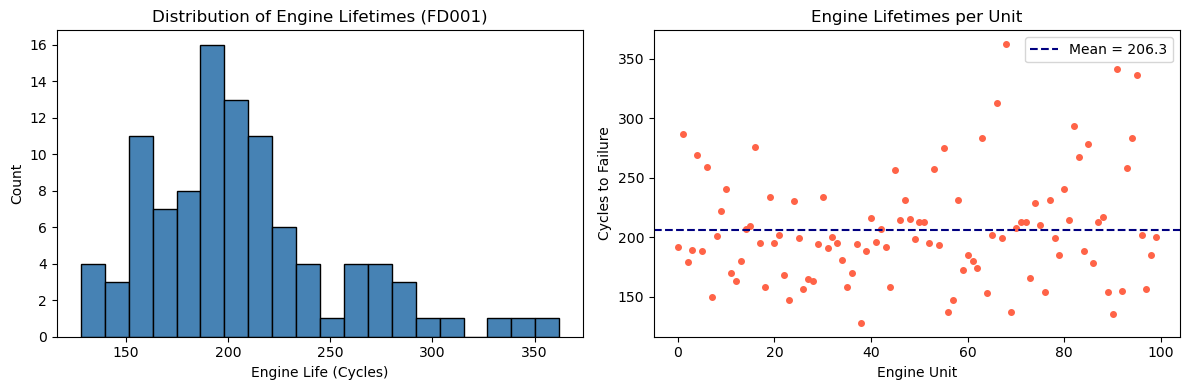

Average engine life: 206.31 cycles


In [4]:
# Engine life distribution
engine_lives = train_df.groupby('unit')['cycle'].max()

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(engine_lives, bins=20, color='steelblue', edgecolor='black')
plt.xlabel('Engine Life (Cycles)')
plt.ylabel('Count')
plt.title('Distribution of Engine Lifetimes (FD001)')

plt.subplot(1, 2, 2)
plt.plot(engine_lives.values, 'o', markersize=4, color='tomato')
plt.axhline(engine_lives.mean(), color='navy', linestyle='--', label=f'Mean = {engine_lives.mean():.1f}')
plt.xlabel('Engine Unit')
plt.ylabel('Cycles to Failure')
plt.title('Engine Lifetimes per Unit')
plt.legend()

plt.tight_layout()
plt.show()
print(f"Average engine life: {engine_lives.mean():.2f} cycles")

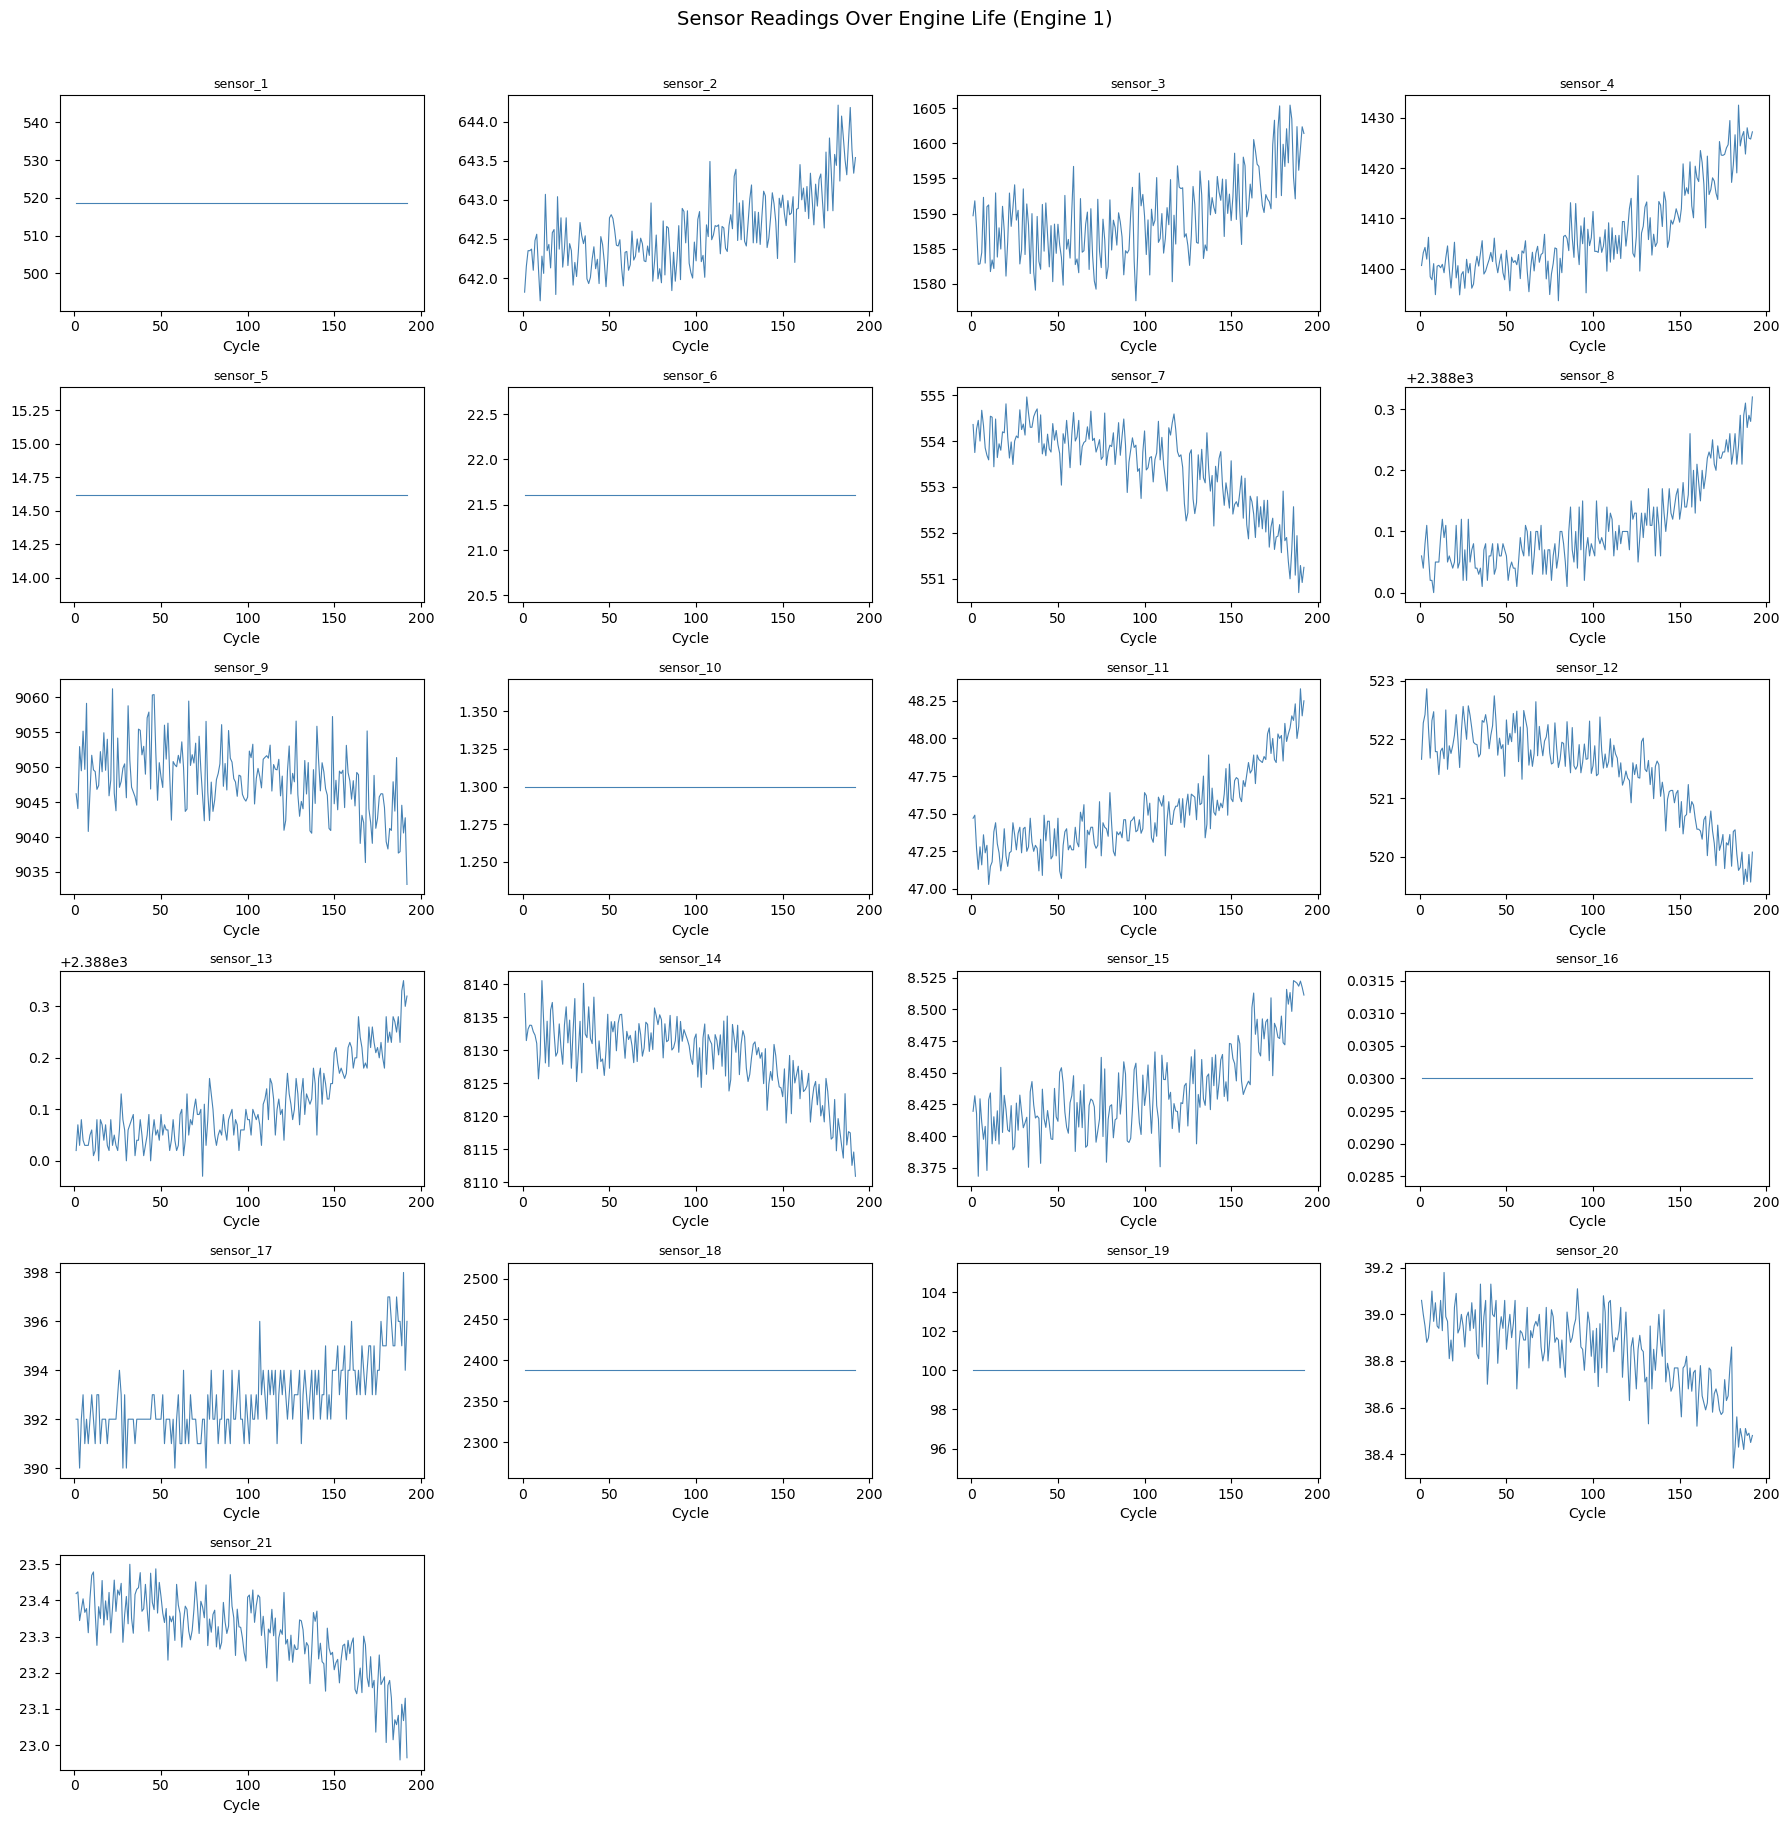

In [5]:
# Sensor trends for one engine over its lifetime
engine_1 = train_df[train_df['unit'] == 1]
sensor_cols = [c for c in train_df.columns if 'sensor' in c]

fig, axes = plt.subplots(6, 4, figsize=(18, 18))
axes = axes.flatten()

for i, col in enumerate(sensor_cols):
    axes[i].plot(engine_1['cycle'], engine_1[col], linewidth=0.8, color='steelblue')
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('Cycle')

# Hide unused subplots
for j in range(len(sensor_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Sensor Readings Over Engine Life (Engine 1)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

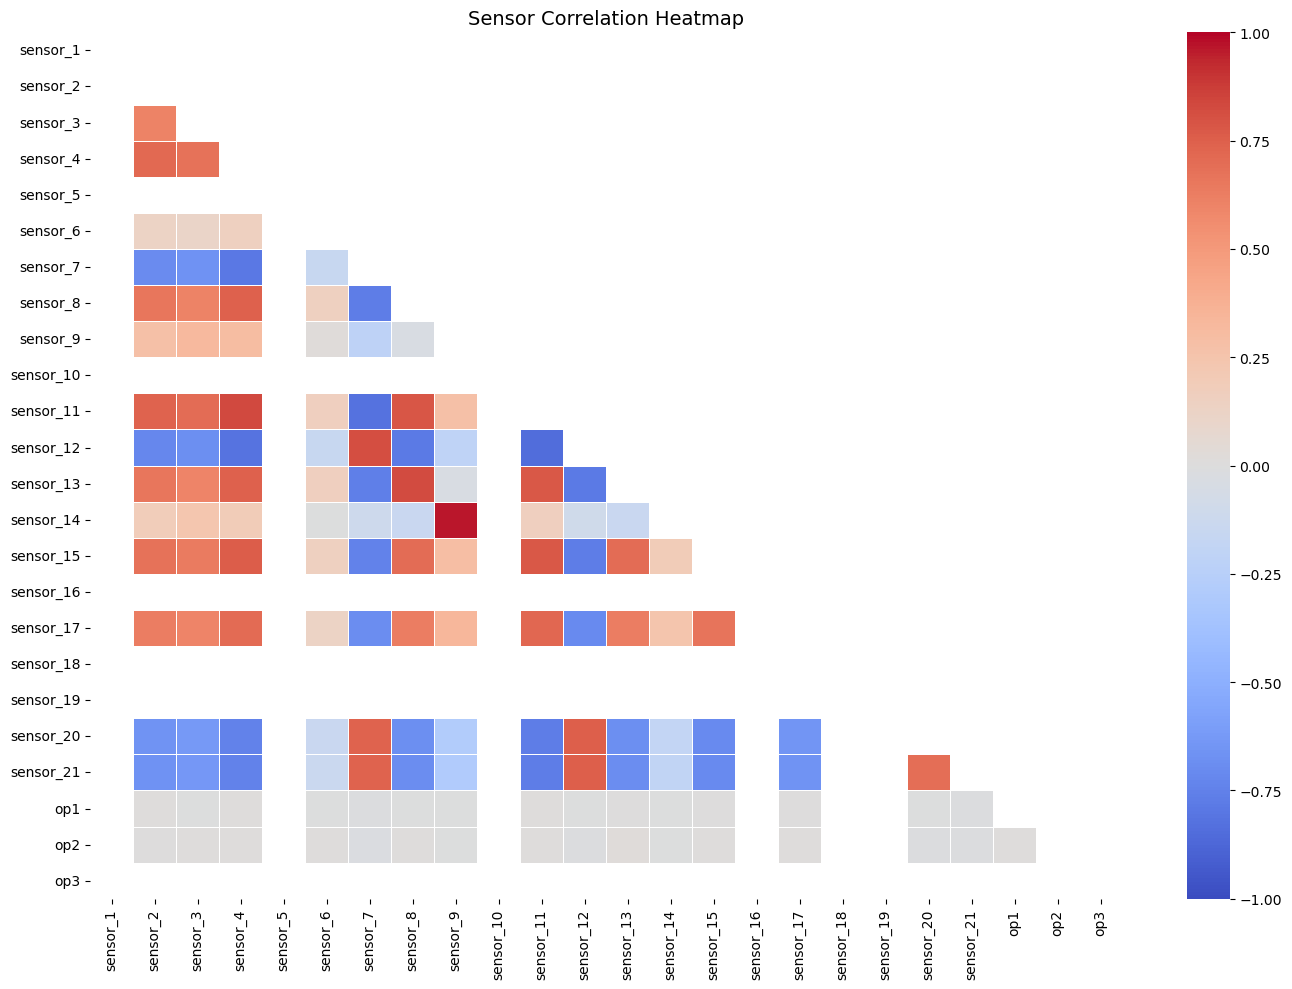

In [6]:
# Correlation heatmap of sensors
plt.figure(figsize=(14, 10))
corr = train_df[sensor_cols + ['op1', 'op2', 'op3']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm', center=0,
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Sensor Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Feature Engineering
### 4.1 Compute RUL Labels for Training Data

In [7]:
def add_rul(df):
    """Add RUL column: RUL = max_cycle - current_cycle for each engine"""
    max_cycles = df.groupby('unit')['cycle'].max().reset_index()
    max_cycles.columns = ['unit', 'max_cycle']
    df = df.merge(max_cycles, on='unit', how='left')
    df['RUL'] = df['max_cycle'] - df['cycle']
    df.drop(columns=['max_cycle'], inplace=True)
    return df

train_df = add_rul(train_df)
print("RUL column added. Sample:")
train_df[['unit', 'cycle', 'RUL']].head(10)

RUL column added. Sample:


,unit,cycle,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187
5,1,6,186
6,1,7,185
7,1,8,184
8,1,9,183
9,1,10,182


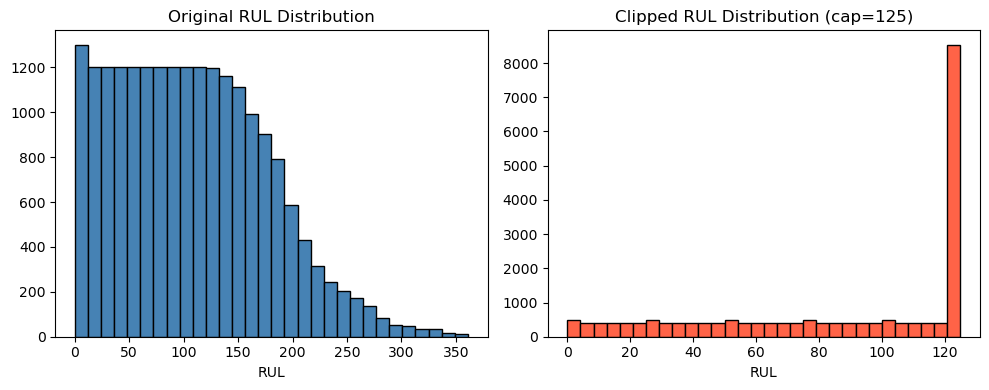

In [8]:
# Clip RUL using piecewise linear degradation model
# Engines are healthy early on — cap RUL at 125 for FD001
RUL_CLIP = 125

train_df['RUL_clipped'] = train_df['RUL'].clip(upper=RUL_CLIP)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(train_df['RUL'], bins=30, color='steelblue', edgecolor='black')
plt.title('Original RUL Distribution')
plt.xlabel('RUL')

plt.subplot(1, 2, 2)
plt.hist(train_df['RUL_clipped'], bins=30, color='tomato', edgecolor='black')
plt.title(f'Clipped RUL Distribution (cap={RUL_CLIP})')
plt.xlabel('RUL')

plt.tight_layout()
plt.show()

### 4.2 Drop Constant / Low-Variance Sensors

In [9]:
# Identify and drop sensors with near-zero variance (uninformative)
sensor_stds = train_df[sensor_cols].std()
low_var = sensor_stds[sensor_stds < 0.01].index.tolist()
print(f"Low-variance sensors to drop: {low_var}")

useful_sensors = [s for s in sensor_cols if s not in low_var]
print(f"Useful sensors remaining: {len(useful_sensors)} → {useful_sensors}")

Low-variance sensors to drop: ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
Useful sensors remaining: 14 → ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


### 4.3 Rolling Window Features

In [10]:
def add_rolling_features(df, sensors, window=5):
    """Add rolling mean and std for each sensor per engine"""
    df = df.sort_values(['unit', 'cycle'])
    for col in sensors:
        df[f'{col}_mean{window}'] = (
            df.groupby('unit')[col]
            .transform(lambda x: x.rolling(window, min_periods=1).mean())
        )
        df[f'{col}_std{window}'] = (
            df.groupby('unit')[col]
            .transform(lambda x: x.rolling(window, min_periods=1).std().fillna(0))
        )
    return df

print("Adding rolling features...")
train_df = add_rolling_features(train_df, useful_sensors, window=5)
test_df  = add_rolling_features(test_df,  useful_sensors, window=5)

print(f"Train shape after feature engineering: {train_df.shape}")

Adding rolling features...
Train shape after feature engineering: (20631, 56)


## 5. Preprocessing

In [11]:
# Define feature columns
feature_cols = useful_sensors + \
               [f'{s}_mean5' for s in useful_sensors] + \
               [f'{s}_std5'  for s in useful_sensors] + \
               ['op1', 'op2', 'op3']

TARGET = 'RUL_clipped'

# Prepare train features/target
X_train_full = train_df[feature_cols].values
y_train_full = train_df[TARGET].values

# For test: take LAST cycle per engine (that's what we predict)
test_last = test_df.groupby('unit').last().reset_index()
X_test = test_last[feature_cols].values
y_test  = rul_df['RUL'].values.clip(0, RUL_CLIP)  # True RUL for test engines

# Scale features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_test_scaled  = scaler.transform(X_test)

# Train/Validation split
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled, y_train_full, test_size=0.2, random_state=42
)

print(f"X_train: {X_tr.shape}, X_val: {X_val.shape}, X_test: {X_test_scaled.shape}")
print(f"y_train range: {y_tr.min():.0f} – {y_tr.max():.0f}")

X_train: (16504, 45), X_val: (4127, 45), X_test: (100, 45)
y_train range: 0 – 125


## 6. Model Training
### 6.1 Baseline – Linear Regression

In [12]:
lr = LinearRegression()
lr.fit(X_tr, y_tr)

val_pred_lr  = lr.predict(X_val)
test_pred_lr = lr.predict(X_test_scaled)

rmse_val  = np.sqrt(mean_squared_error(y_val, val_pred_lr))
rmse_test = np.sqrt(mean_squared_error(y_test, test_pred_lr))
print(f"Linear Regression | Val RMSE: {rmse_val:.2f} | Test RMSE: {rmse_test:.2f}")

Linear Regression | Val RMSE: 21.23 | Test RMSE: 21.03


### 6.2 Random Forest Regressor

In [13]:
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)

val_pred_rf  = rf.predict(X_val)
test_pred_rf = rf.predict(X_test_scaled)

rmse_val_rf  = np.sqrt(mean_squared_error(y_val, val_pred_rf))
rmse_test_rf = np.sqrt(mean_squared_error(y_test, test_pred_rf))
print(f"Random Forest      | Val RMSE: {rmse_val_rf:.2f} | Test RMSE: {rmse_test_rf:.2f}")

Random Forest      | Val RMSE: 16.52 | Test RMSE: 17.89


### 6.3 Gradient Boosting Regressor

In [14]:
gbr = GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                 learning_rate=0.05, random_state=42)
gbr.fit(X_tr, y_tr)

val_pred_gbr  = gbr.predict(X_val)
test_pred_gbr = gbr.predict(X_test_scaled)

rmse_val_gbr  = np.sqrt(mean_squared_error(y_val, val_pred_gbr))
rmse_test_gbr = np.sqrt(mean_squared_error(y_test, test_pred_gbr))
print(f"Gradient Boosting  | Val RMSE: {rmse_val_gbr:.2f} | Test RMSE: {rmse_test_gbr:.2f}")

Gradient Boosting  | Val RMSE: 17.13 | Test RMSE: 17.37


### 6.4 LSTM (Deep Learning) – Optional

In [15]:
if DEEP_LEARNING:
    SEQUENCE_LEN = 30

    def create_sequences(df, sensors, target, seq_len):
        """Create sliding window sequences per engine."""
        X_seq, y_seq = [], []
        for unit in df['unit'].unique():
            eng = df[df['unit'] == unit].sort_values('cycle')
            feat = scaler.transform(eng[feature_cols].values)
            tgt  = eng[target].values
            for i in range(seq_len, len(feat)):
                X_seq.append(feat[i-seq_len:i])
                y_seq.append(tgt[i])
        return np.array(X_seq), np.array(y_seq)

    print("Creating sequences...")
    X_seq, y_seq = create_sequences(train_df, feature_cols, TARGET, SEQUENCE_LEN)
    X_seq_tr, X_seq_val, y_seq_tr, y_seq_val = train_test_split(
        X_seq, y_seq, test_size=0.2, random_state=42
    )
    print(f"Sequence shape: {X_seq_tr.shape}")

    # LSTM Model
    lstm_model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(SEQUENCE_LEN, len(feature_cols))),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])

    lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    lstm_model.summary()

    es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = lstm_model.fit(
        X_seq_tr, y_seq_tr,
        validation_data=(X_seq_val, y_seq_val),
        epochs=50, batch_size=64, callbacks=[es], verbose=1
    )

    # Plot training history
    plt.figure(figsize=(10, 4))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.title('LSTM Training History')
    plt.legend()
    plt.show()
else:
    print("⚠️ Skipping LSTM — TensorFlow not installed.")

⚠️ Skipping LSTM — TensorFlow not installed.


## 7. Model Evaluation & Comparison

In [16]:
def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return {'Model': name, 'RMSE': round(rmse, 2), 'MAE': round(mae, 2), 'R2': round(r2, 4)}

results = [
    evaluate('Linear Regression', y_test, test_pred_lr),
    evaluate('Random Forest',     y_test, test_pred_rf),
    evaluate('Gradient Boosting', y_test, test_pred_gbr),
]

results_df = pd.DataFrame(results).sort_values('RMSE')
print("\n📊 Model Comparison on Test Set:")
print(results_df.to_string(index=False))


📊 Model Comparison on Test Set:
            Model  RMSE   MAE     R2
Gradient Boosting 17.37 12.14 0.8121
    Random Forest 17.89 12.57 0.8007
Linear Regression 21.03 16.70 0.7246


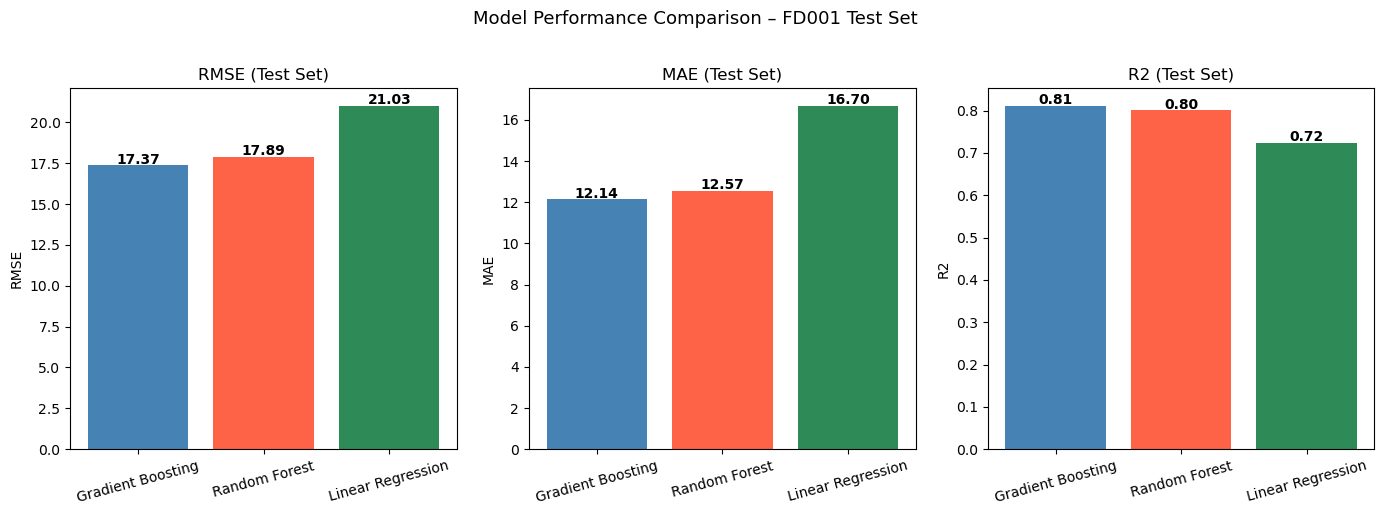

In [17]:
# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, metric in zip(axes, ['RMSE', 'MAE', 'R2']):
    bars = ax.bar(results_df['Model'], results_df[metric],
                  color=['steelblue', 'tomato', 'seagreen'])
    ax.set_title(f'{metric} (Test Set)', fontsize=12)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005 * bar.get_height(),
                f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Model Performance Comparison – FD001 Test Set', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 8. Best Model Analysis

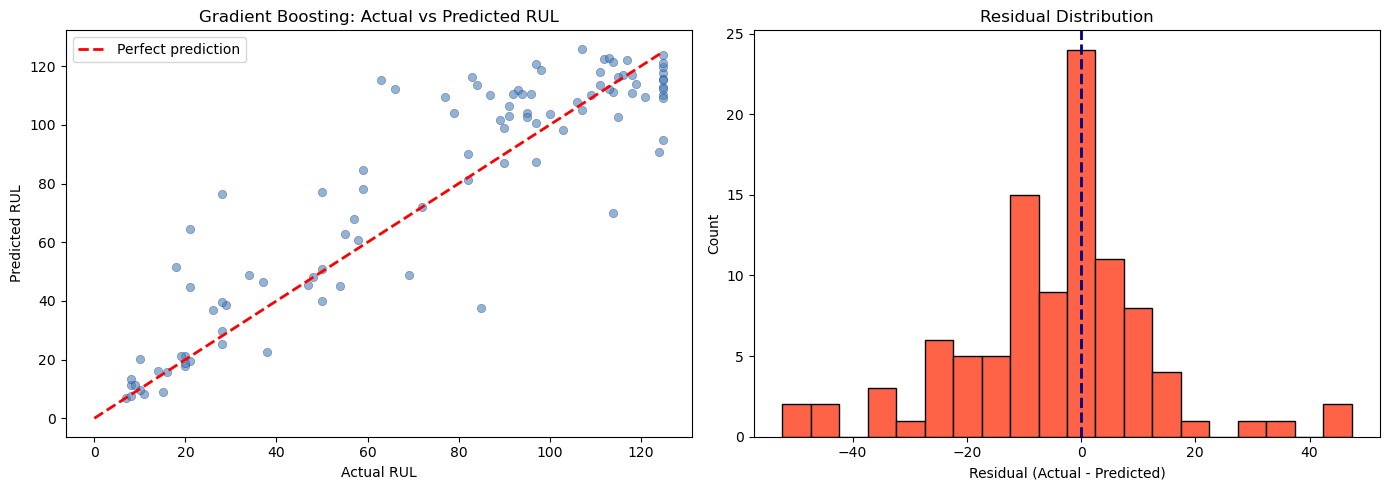

In [18]:
# Use best model (GBR typically wins on this dataset)
best_pred = test_pred_gbr
best_name = 'Gradient Boosting'

# Actual vs Predicted plot
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, best_pred, alpha=0.6, color='steelblue', edgecolors='navy', linewidths=0.3)
plt.plot([0, RUL_CLIP], [0, RUL_CLIP], 'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual RUL')
plt.ylabel('Predicted RUL')
plt.title(f'{best_name}: Actual vs Predicted RUL')
plt.legend()

plt.subplot(1, 2, 2)
residuals = y_test - best_pred
plt.hist(residuals, bins=20, color='tomato', edgecolor='black')
plt.axvline(0, color='navy', linestyle='--', lw=2)
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Count')
plt.title('Residual Distribution')

plt.tight_layout()
plt.show()

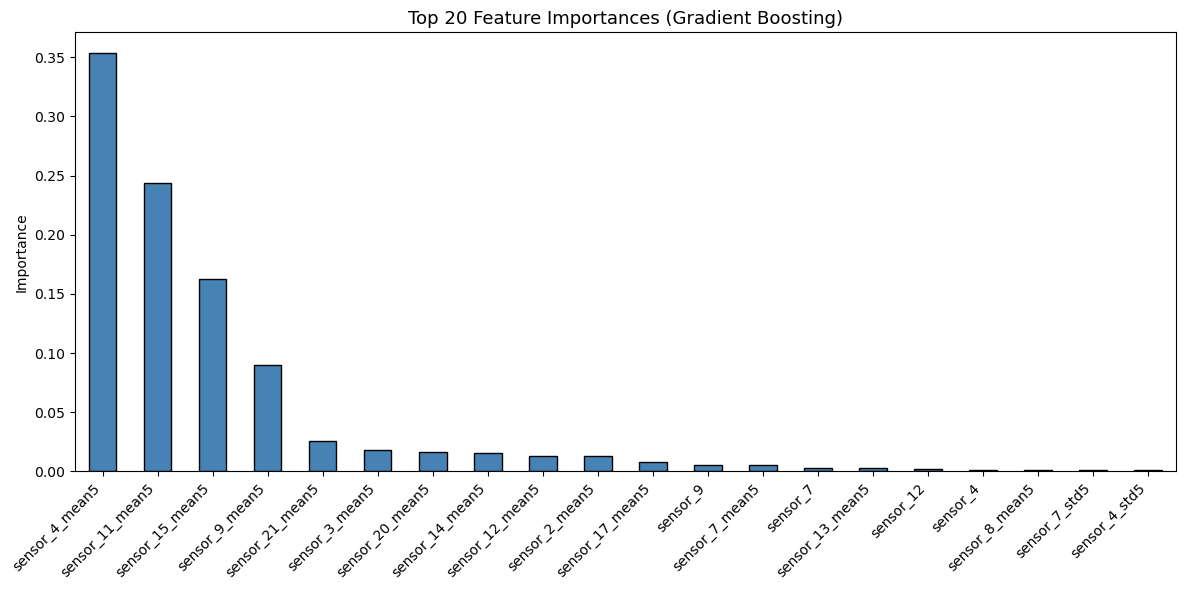

In [19]:
# Feature Importance (for tree-based models)
importances = gbr.feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
feat_imp.head(20).plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 20 Feature Importances (Gradient Boosting)', fontsize=13)
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 9. Run on All 4 Datasets

In [ ]:
def full_pipeline(dataset_id, rul_clip=125):
    """Full train-evaluate pipeline for a given FD dataset."""
    # Load
    train, test, rul = load_data(dataset_id)

    # RUL label
    train = add_rul(train)
    train['RUL_clipped'] = train['RUL'].clip(upper=rul_clip)

    # Sensors
    s_cols = [c for c in train.columns if 'sensor' in c]
    stds   = train[s_cols].std()
    s_use  = stds[stds >= 0.01].index.tolist()

    # Rolling features
    train = add_rolling_features(train, s_use)
    test  = add_rolling_features(test,  s_use)

    f_cols = s_use + [f'{s}_mean5' for s in s_use] + \
             [f'{s}_std5' for s in s_use] + ['op1','op2','op3']

    X = train[f_cols].values
    y = train['RUL_clipped'].values

    test_last = test.groupby('unit').last().reset_index()
    X_t = test_last[f_cols].values
    y_t = rul['RUL'].values.clip(0, rul_clip)

    sc = MinMaxScaler()
    X_s  = sc.fit_transform(X)
    X_ts = sc.transform(X_t)

    X_tr, X_v, y_tr, y_v = train_test_split(X_s, y, test_size=0.2, random_state=42)

    model = GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                       learning_rate=0.05, random_state=42)
    model.fit(X_tr, y_tr)
    preds = model.predict(X_ts)

    rmse = np.sqrt(mean_squared_error(y_t, preds))
    mae  = mean_absolute_error(y_t, preds)
    r2   = r2_score(y_t, preds)

    return {'Dataset': f'FD00{dataset_id}', 'RMSE': round(rmse,2),
            'MAE': round(mae,2), 'R2': round(r2,4)}

print("Running pipeline on all datasets (this may take ~1 min)...")
all_results = [full_pipeline(i) for i in [1, 2, 3, 4]]
all_df = pd.DataFrame(all_results)

print("\n📊 Gradient Boosting Results – All Datasets:")
print(all_df.to_string(index=False))

Running pipeline on all datasets (this may take ~1 min)...


In [ ]:
# Visualize all datasets
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(all_df))
bars = ax.bar(x, all_df['RMSE'], color=['steelblue','tomato','seagreen','darkorange'],
              edgecolor='black', width=0.5)
ax.set_xticks(x)
ax.set_xticklabels(all_df['Dataset'])
ax.set_ylabel('RMSE (cycles)')
ax.set_title('Test RMSE Across All 4 Datasets – Gradient Boosting', fontsize=13)
for bar, val in zip(bars, all_df['RMSE']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Summary & Conclusions

| Model | Strength | Weakness |
|---|---|---|
| Linear Regression | Fast, interpretable | Low accuracy, linear only |
| Random Forest | Robust, handles noise | Slower training |
| Gradient Boosting | Best accuracy | Needs tuning |
| LSTM | Captures temporal patterns | Needs GPU, more data |

### Key Findings:
1. **FD001 is easiest** (1 condition, 1 fault) — expect lowest RMSE ~15–20 cycles
2. **FD004 is hardest** (6 conditions, 2 faults) — RMSE typically ~30–40 cycles
3. **Sensor clipping** at RUL=125 significantly helps model convergence
4. **Rolling statistics** (mean/std over 5 cycles) are among the most important features
5. Several sensors have near-zero variance and should be dropped
